In [1]:
library(tidyverse)
library(dplyr)

install.packages("showtext")
install.packages("extrafont")
library(extrafont)
font_import()


theme_rangeframe <- function(size = 0.3) {
    theme(
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )
}

scale_axis_rangeframe <- function() {
    guides(x = "axis_truncated", y = "axis_truncated")
}

rotate_x_text <- function(angle=45) {
    theme(
        axis.text.x = element_text(angle = angle, hjust = 1)
    )
}

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}

no_legend <- function() {
    theme(
        legend.position = "none"
    )
}

no_margin <- function() {
    theme(
        plot.margin = margin(0, 0, 0, 0, unit = "lines")
    )
}

no_label <- function() {
    theme(
        axis.title = element_blank()
    )
}

no_text <- function() {
    theme(
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank()
    )
}

no_x_text <- function() {
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )
}

no_y_text <- function() {
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )
}


custom_theme <- function(size = 0.3){
    theme_minimal() +
    theme(
        text = element_text(family='Helvetica'),
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )

}
theme_set(custom_theme())

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}


Warning message:
“package ‘tidyverse’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘readr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”
Warning message:
“package ‘lubridate’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package 

Importing fonts may take a few minutes, depending on the number of fonts and the speed of the system.
Continue? [y/n]  y


Scanning ttf files in /usr/share/fonts/ ...

Extracting .afm files from .ttf files...

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-Bold.ttf
 : DejaVuSans-Bold already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-BoldOblique.ttf
 : DejaVuSans-BoldOblique already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-ExtraLight.ttf
 : DejaVuSans-ExtraLight already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-Oblique.ttf
 : DejaVuSans-Oblique already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans.ttf
 : DejaVuSans already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSansCondensed-Bold.ttf
 : DejaVuSansCondensed-Bold already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSansCondensed-BoldOblique.ttf
 : DejaVuSansCondensed-BoldOblique already registered in fonts d

In [2]:
color_dict = c(
    "CellFlow"= "#B12F8C",
    "Mean model 1"= "#8F97A8",
    "Mean model 2"= "#566573",
    "Identity"="#BDBDBD",
    "Closest embedding" = "#E0E0E0")

In [3]:
output_dir <- "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc_new_donor/scaling_law"

In [4]:
df <- read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/scaling_law.csv")

New names:
• `` -> `...1`
Rows: 40 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): method
dbl (5): ...1, num_cytokines_in_train, ood_e_distance, log2_num_cytokines_in...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
“There were 3 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r_squared = `$`(...)`.
ℹ In group 2: `method = "cl_emb"`.
Caused by warning in `summary.lm()`:
! essentially perfect fit: summary may be unreliable
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


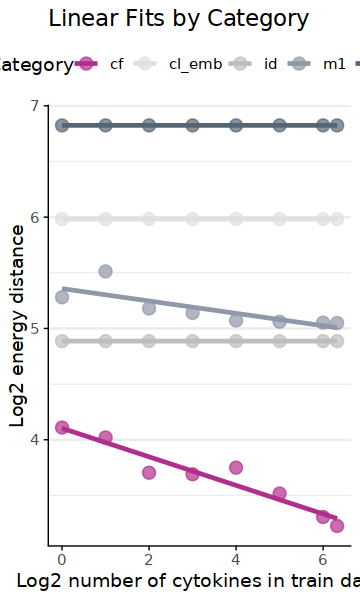

In [7]:
options(repr.plot.width = 3, repr.plot.height = 5)
# Compute Slopes for Each Category
slopes <- df %>%
  group_by(method) %>%
  summarise(slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2])  # Extract slope coefficient



# Compute Slopes and R² for Each Category
model_stats <- df %>%
  group_by(method) %>%
  summarise(
    slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2],  # Extract slope
    r_squared = summary(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))$r.squared  # Extract R²
  )


# Define colors for categories
color_dict <- c(
  "cf"= "#B12F8C",
  "m1"= "#8F97A8",
  "m2"= "#566573",
  "id"= "#BDBDBD",
  "cl_emb"="#E0E0E0"
)
# Plot with linear fits
p <- ggplot(df, aes(x=log2_num_cytokines_in_train, y=log2_ood_e_distance, color=method)) +
  geom_point(size=3, alpha=0.7) +  # Data points
  geom_smooth(method="lm", se=FALSE, size=1) +  # Linear fit lines
  scale_color_manual(values=color_dict) +  # Custom colors
  custom_theme() +
  theme(panel.grid.major.x = element_blank(), 
      panel.grid.minor.x = element_blank()) + 
  labs(title="Linear Fits by Category",
       x="Log2 number of cytokines in train data",
       y="Log2 energy distance",
       color="Category") +
  theme(legend.position="top")
p

In [8]:
model_stats

method,slope,r_squared
<chr>,<dbl>,<dbl>
cf,-1.283263e-01,0.9160890
cl_emb,3.096546e-16,0.4498362
id,-9.873355e-17,0.5407852
m1,-5.556626e-02,0.6436804
m2,4.384248e-16,0.5037975


In [9]:
ggsave(file.path(output_dir, "scaling_law_new_donor.pdf"), plot = p, device = "pdf",width = 2, height = 5)

`geom_smooth()` using formula = 'y ~ x'


In [10]:
options(repr.plot.width = 2, repr.plot.height = 5)

df <- df %>%
  filter(log2_num_cytokines_in_train > 3) 

# Compute Slopes for Each Category
slopes <- df %>%
  group_by(method) %>%
  summarise(slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2])  # Extract slope coefficient



# Compute Slopes and R² for Each Category
model_stats <- df %>%
  group_by(method) %>%
  summarise(
    slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2],  # Extract slope
    r_squared = summary(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))$r.squared  # Extract R²
  )


# Define colors for categories
color_dict <- c(
  "cf"= "#B12F8C",
  "m1"= "#8F97A8",
  "m2"= "#566573",
  "id"= "#BDBDBD",
  "cl_emb"="#E0E0E0"
)
# Plot with linear fits
p <- ggplot(df, aes(x=log2_num_cytokines_in_train, y=log2_ood_e_distance, color=method)) +
  geom_point(size=3, alpha=0.7) +  # Data points
  geom_smooth(method="lm", se=FALSE, size=1) +  # Linear fit lines
  scale_color_manual(values=color_dict) +  # Custom colors
  custom_theme() +
  theme(panel.grid.major.x = element_blank(), 
      panel.grid.minor.x = element_blank()) + 
  labs(title="Linear Fits by Category",
       x="Log2 number of cytokines in train data",
       y="Log2 energy distance",
       color="Category") +
  theme(legend.position="top")


Warning message:
“There were 3 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r_squared = `$`(...)`.
ℹ In group 2: `method = "cl_emb"`.
Caused by warning in `summary.lm()`:
! essentially perfect fit: summary may be unreliable
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


`geom_smooth()` using formula = 'y ~ x'


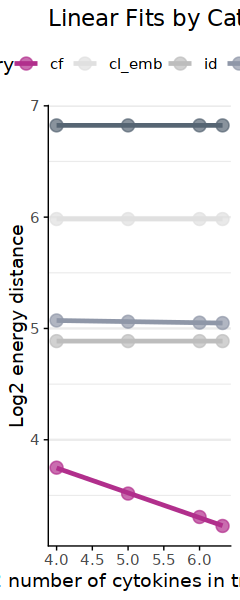

In [11]:
p

In [12]:
model_stats

method,slope,r_squared
<chr>,<dbl>,<dbl>
cf,-2.231592e-01,0.9994131
cl_emb,0.000000e+00,NaN
id,0.000000e+00,NaN
m1,-9.880973e-03,0.9941169
m2,7.138876e-16,0.5372856


In [13]:
ggsave(file.path(output_dir, "scaling_law_new_donor_reduced.pdf"), plot = p, device = "pdf",width = 2, height = 5)

`geom_smooth()` using formula = 'y ~ x'


In [14]:
df <- read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/scaling_law_two_curves.csv")

New names:
• `` -> `...1`
Rows: 60 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): method
dbl (5): ...1, num_cytokines_in_train, ood_e_distance, log2_num_cytokines_in...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
options(repr.plot.width = 2, repr.plot.height = 5)


# Compute Slopes for Each Category
slopes <- df %>%
  group_by(method) %>%
  summarise(slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2])  # Extract slope coefficient



# Compute Slopes and R² for Each Category
model_stats <- df %>%
  group_by(method) %>%
  summarise(
    slope = coef(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))[2],  # Extract slope
    r_squared = summary(lm(log2_ood_e_distance ~ log2_num_cytokines_in_train, data = cur_data()))$r.squared  # Extract R²
  )


# Define colors for categories
color_dict <- c(
  "cf"= "#B12F8C",
  "m1"= "#8F97A8",
  "m2"= "#566573",
  "id"= "#BDBDBD",
  "cl_emb"="#E0E0E0",
  "cf_red"= "#B12F8C",
  "m1_red"= "#8F97A8",
  "m2_red"= "#566573",
  "id_red"= "#BDBDBD",
  "cl_emb_red"="#E0E0E0"
)
# Plot with linear fits
p <- ggplot(df, aes(x=log2_num_cytokines_in_train, y=log2_ood_e_distance, color=method)) +
  geom_point(size=3, alpha=0.7) +  # Data points
  geom_smooth(method="lm", se=FALSE, size=1) +  # Linear fit lines
  scale_color_manual(values=color_dict) +  # Custom colors
  custom_theme() +
  theme(panel.grid.major.x = element_blank(), 
      panel.grid.minor.x = element_blank()) + 
  labs(title="Linear Fits by Category",
       x="Log2 number of cytokines in train data",
       y="Log2 energy distance",
       color="Category") +
  theme(legend.position="top")


Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r_squared = `$`(...)`.
ℹ In group 3: `method = "cl_emb"`.
Caused by warning in `summary.lm()`:
! essentially perfect fit: summary may be unreliable
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


`geom_smooth()` using formula = 'y ~ x'


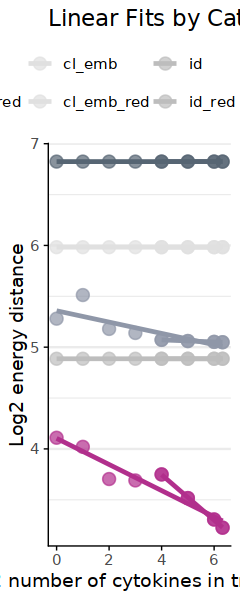

In [16]:
p

In [17]:
# Define linetype mapping: dashed for non-"_red", solid for "_red"
df$linetype <- ifelse(grepl("_red$", df$method), "solid", "dashed")

# Plot with linear fits
p <- ggplot(df, aes(x=log2_num_cytokines_in_train, y=log2_ood_e_distance, 
                     color=method, linetype=linetype)) +
  geom_point(size=3, alpha=0.7) +  # Data points
  geom_smooth(method="lm", se=FALSE, size=1) +  # Linear fit lines
  scale_color_manual(values=color_dict) +  # Custom colors
  scale_linetype_identity() +  # Use the defined linetypes without mapping to legend
  custom_theme() +
  theme(panel.grid.major.x = element_blank(), 
        panel.grid.minor.x = element_blank()) + 
  labs(title="Linear Fits by Category",
       x="Log2 number of cytokines in train data",
       y="Log2 energy distance",
       color="Category") +
  theme(legend.position="top")


`geom_smooth()` using formula = 'y ~ x'


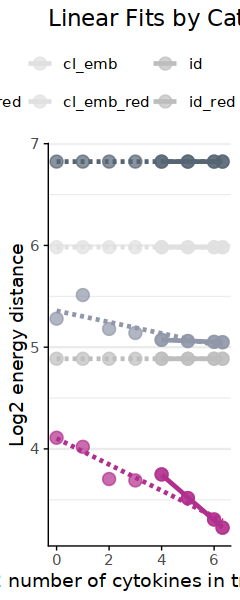

In [18]:
p

In [19]:
ggsave(file.path(output_dir, "scaling_law_combined.pdf"), plot = p, device = "pdf",width = 2, height = 5)

`geom_smooth()` using formula = 'y ~ x'
